In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
np.random.seed(42)
n = 2000

data = {
    'customer_id':     range(1, n+1),
    'age':             np.random.randint(22, 60, n),
    'monthly_income':  np.random.randint(10000, 80000, n),
    'loan_amount':     np.random.randint(50000, 500000, n),
    'loan_tenure':     np.random.randint(12, 60, n),  # in months
    'cibil_score':     np.random.randint(300, 900, n),
    'num_of_loans':    np.random.randint(0, 5, n),
    'city':            np.random.choice(['Mumbai', 'Delhi', 'Jaipur', 'Chennai', 'Pune'], n),
    'defaulted':       np.random.choice([0, 1], n, p=[0.7, 0.3])  # 70% no default, 30% default
}

df = pd.DataFrame(data)

In [4]:
df

,customer_id,age,monthly_income,loan_amount,loan_tenure,cibil_score,num_of_loans,city,defaulted
0,1,50,34226,477214,42,504,0,Jaipur,0
1,2,36,16721,470446,42,686,1,Chennai,0
2,3,29,66154,190148,28,767,0,Mumbai,1
3,4,42,30609,119341,35,714,3,Mumbai,1
4,5,40,62130,81085,34,368,3,Pune,1
...,...,...,...,...,...,...,...,...,...
1995,1996,28,52788,58802,46,784,0,Pune,0
1996,1997,35,56830,221277,23,355,0,Delhi,0
1997,1998,30,62446,346303,41,522,2,Delhi,1
1998,1999,36,25160,61516,16,478,1,Delhi,0


In [5]:
df.loc[5:15, 'cibil_score'] = np.nan
df.loc[20:25, 'monthly_income'] = np.nan
df.loc[0, 'monthly_income'] = 5000000
df.loc[1, 'loan_amount'] = 9999999

In [6]:
df.shape

(2000, 9)

In [10]:
df.groupby('defaulted').mean(numeric_only=True)

,customer_id,age,monthly_income,loan_amount,loan_tenure,cibil_score,num_of_loans
defaulted,,,,,,,
0,1006.075714,40.758571,47665.686022,285241.021429,34.875000,599.061782,2.055000
1,987.490000,40.911667,44846.217028,281910.533333,35.266667,594.825796,2.116667


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     2000 non-null   int64  
 1   age             2000 non-null   int32  
 2   monthly_income  1994 non-null   float64
 3   loan_amount     2000 non-null   int32  
 4   loan_tenure     2000 non-null   int32  
 5   cibil_score     1989 non-null   float64
 6   num_of_loans    2000 non-null   int32  
 7   city            2000 non-null   object 
 8   defaulted       2000 non-null   int64  
dtypes: float64(2), int32(4), int64(2), object(1)
memory usage: 109.5+ KB


In [13]:
df.isnull().sum().sort_values(ascending=False)

cibil_score       11
monthly_income     6
customer_id        0
loan_amount        0
age                0
loan_tenure        0
num_of_loans       0
city               0
defaulted          0
dtype: int64

In [14]:
df.describe()

,customer_id,age,monthly_income,loan_amount,loan_tenure,cibil_score,num_of_loans,defaulted
count,2000.000000,2000.000000,1.994000e+03,2.000000e+03,2000.000000,1989.000000,2000.000000,2000.000000
mean,1000.500000,40.804500,4.681871e+04,2.842419e+05,34.992500,597.790347,2.073500,0.300000
std,577.494589,11.079019,1.127830e+05,2.532146e+05,13.765325,172.731703,1.419192,0.458372
min,1.000000,22.000000,1.011200e+04,5.032000e+04,12.000000,300.000000,0.000000,0.000000
25%,500.750000,31.000000,2.731625e+04,1.671300e+05,23.000000,446.000000,1.000000,0.000000
50%,1000.500000,41.000000,4.337250e+04,2.834040e+05,35.000000,594.000000,2.000000,0.000000
75%,1500.250000,50.000000,6.172450e+04,3.904192e+05,47.000000,746.000000,3.000000,1.000000
max,2000.000000,59.000000,5.000000e+06,9.999999e+06,59.000000,899.000000,4.000000,1.000000


In [16]:
df.groupby('city')['defaulted'].sum().sort_values(ascending=False)

city
Delhi      133
Chennai    126
Mumbai     120
Jaipur     114
Pune       107
Name: defaulted, dtype: int64

In [17]:
df.columns

Index(['customer_id', 'age', 'monthly_income', 'loan_amount', 'loan_tenure',
       'cibil_score', 'num_of_loans', 'city', 'defaulted'],
      dtype='object')

In [18]:
df['cibil_score'].fillna(df['cibil_score'].median(),inplace=True)

In [19]:
df['monthly_income'].fillna(df['monthly_income'].median(),inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     2000 non-null   int64  
 1   age             2000 non-null   int32  
 2   monthly_income  2000 non-null   float64
 3   loan_amount     2000 non-null   int32  
 4   loan_tenure     2000 non-null   int32  
 5   cibil_score     2000 non-null   float64
 6   num_of_loans    2000 non-null   int32  
 7   city            2000 non-null   object 
 8   defaulted       2000 non-null   int64  
dtypes: float64(2), int32(4), int64(2), object(1)
memory usage: 109.5+ KB


Text(0.5, 1.0, 'Default Rate by City')

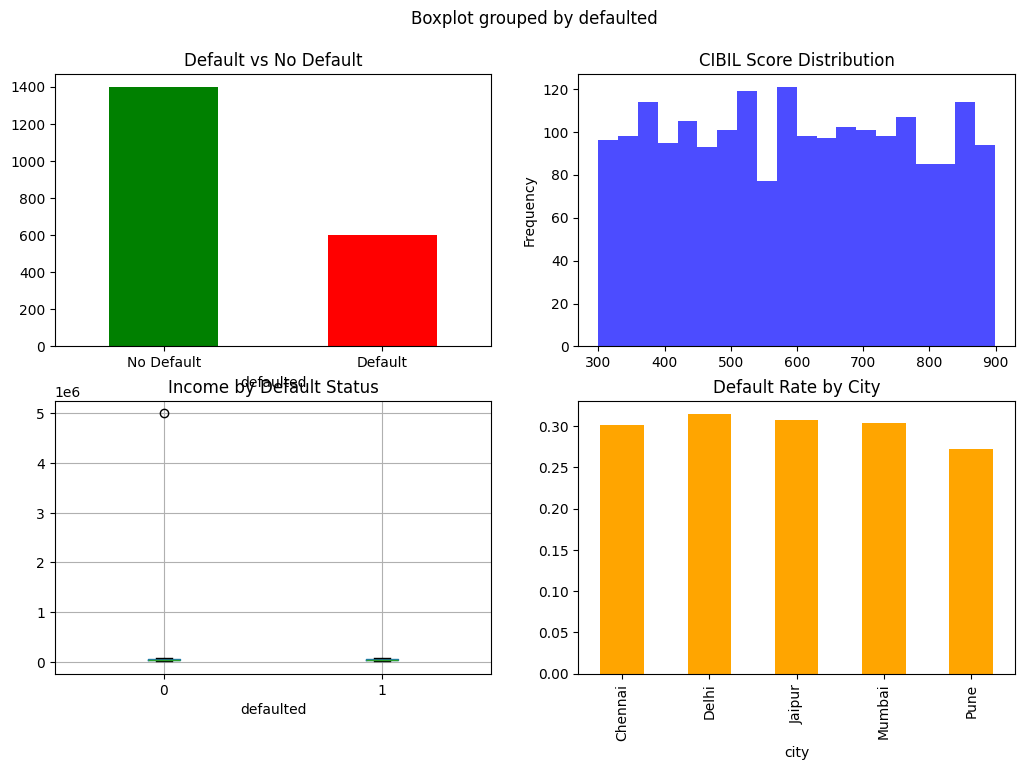

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('NBFC Customer Data Analysis', fontsize=16)

# 1. Default Rate
df['defaulted'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green','red'])
axes[0,0].set_title('Default vs No Default')
axes[0,0].set_xticklabels(['No Default', 'Default'], rotation=0)

df['cibil_score'].plot(kind='hist', ax=axes[0,1], bins=20, color='blue', alpha=0.7)
axes[0,1].set_title('CIBIL Score Distribution')


# 3. Income vs Default
df.boxplot(column='monthly_income', by='defaulted', ax=axes[1,0])
axes[1,0].set_title('Income by Default Status')

# 4. City wise defaults
df.groupby('city')['defaulted'].mean().plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title('Default Rate by City')

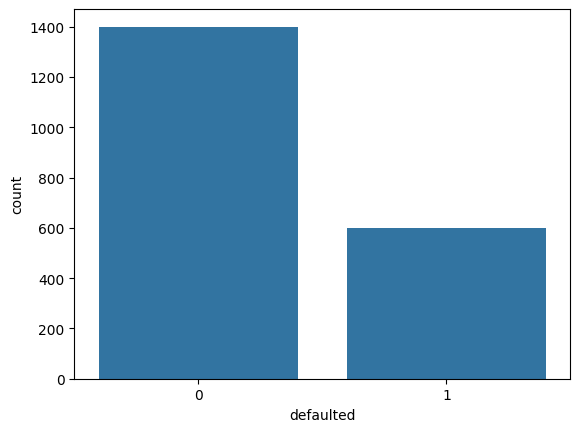

In [26]:
sns.barplot(df['defaulted'].value_counts())
plt.show()

Text(0.5, 1.0, 'CIBIL Score Distribution')

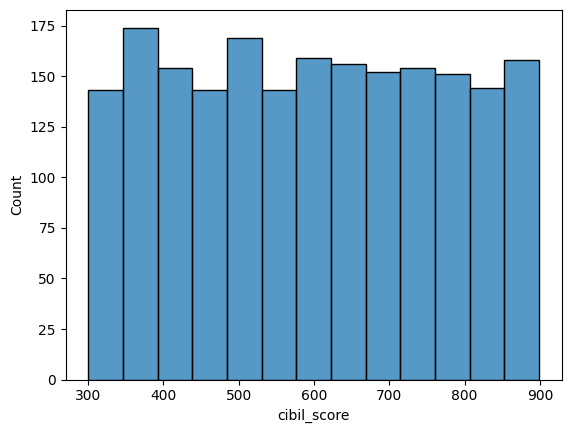

In [29]:
sns.histplot(df['cibil_score'])
plt.show()

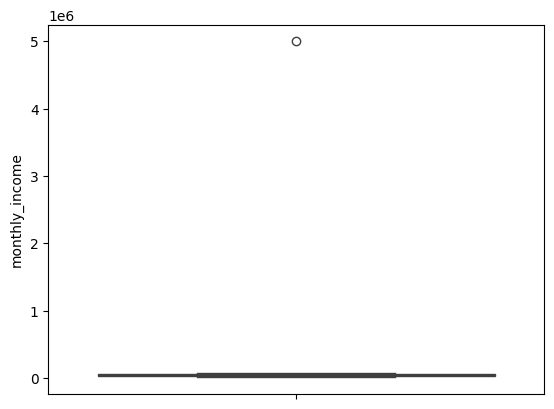

In [ ]:
sns.boxplot(df['monthly_income'])
plt.show()

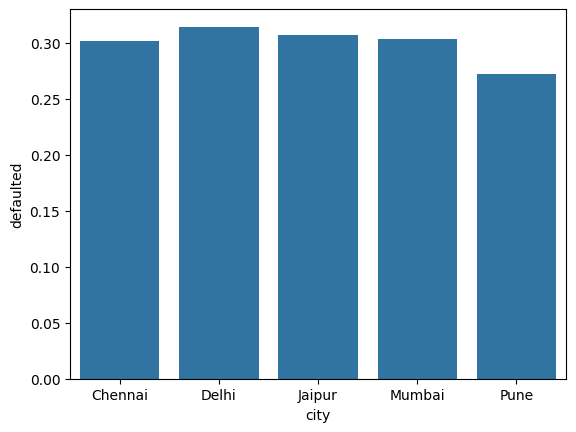

In [35]:
sns.barplot(df.groupby('city')['defaulted'].mean())
plt.show()

In [36]:
# Use other columns to predict the missing column
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[['monthly_income', 'cibil_score']] = imputer.fit_transform(
    df[['monthly_income', 'cibil_score']]
)

In [37]:
df.head()

,customer_id,age,monthly_income,loan_amount,loan_tenure,cibil_score,num_of_loans,city,defaulted
0,1,50,5000000.0,477214,42,504.0,0,Jaipur,0
1,2,36,16721.0,9999999,42,686.0,1,Chennai,0
2,3,29,66154.0,190148,28,767.0,0,Mumbai,1
3,4,42,30609.0,119341,35,714.0,3,Mumbai,1
4,5,40,62130.0,81085,34,368.0,3,Pune,1


In [38]:
df['city'].unique()

array(['Jaipur', 'Chennai', 'Mumbai', 'Pune', 'Delhi'], dtype=object)

In [39]:
from sklearn.preprocessing import OneHotEncoder

In [42]:
c = df[['city']]

In [43]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(c)

In [44]:
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['city']))

In [45]:
df = df.drop('city', axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [46]:
df.head()

,customer_id,age,monthly_income,loan_amount,loan_tenure,cibil_score,num_of_loans,defaulted,city_Chennai,city_Delhi,city_Jaipur,city_Mumbai,city_Pune
0,1,50,5000000.0,477214,42,504.0,0,0,0.0,0.0,1.0,0.0,0.0
1,2,36,16721.0,9999999,42,686.0,1,0,1.0,0.0,0.0,0.0,0.0
2,3,29,66154.0,190148,28,767.0,0,1,0.0,0.0,0.0,1.0,0.0
3,4,42,30609.0,119341,35,714.0,3,1,0.0,0.0,0.0,1.0,0.0
4,5,40,62130.0,81085,34,368.0,3,1,0.0,0.0,0.0,0.0,1.0


In [47]:
from sklearn.model_selection import train_test_split

In [49]:
x = df.drop('defaulted',axis='columns')
y = df['defaulted']

In [50]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2)

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
model = LogisticRegression()

In [53]:
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
model.score(x_test,y_test)

0.6725

In [55]:
from sklearn import tree

In [56]:
model_t = tree.DecisionTreeClassifier()

In [57]:
model_t.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [59]:
model_t.score(x_test,y_test)

0.5625

In [60]:
from sklearn.svm import SVC

In [61]:
model_s = SVC()

In [62]:
model_s.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [63]:
model_s.score(x_test,y_test)

0.6725

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
model_f = RandomForestClassifier(n_estimators=20)

In [66]:
model_f.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [67]:
model_f.score(x_test,y_test)

0.66